# Pregunta 2 — Ecualización local y control de contraste

### Importaciones necesarias

In [1]:
import matplotlib.pyplot as plt
import skimage as sk
import numpy as np
import os

## Implementación

### Función de distribución acumulada (CDF)

Calcula la suma acumulada del histograma y la normaliza para obtener la función de distribución acumulada.

In [2]:
# Calcular la función de distribución acumulada
def calcular_cdf(hist):
    cdf = np.cumsum(hist, dtype=np.float64)
    if cdf[-1] > 0:
        cdf /= cdf[-1]
    return cdf

### Función de control de contraste

Limita los valores máximos del histograma según `factor` y redistribuye uniformemente el exceso para reducir la amplificación del contraste.

In [3]:
def control_contraste(hist, factor):

    if factor >= 1.0 or factor <= 0:
        return hist.copy()
    
    # Umbral absoluto basado en la masa total y el número de bins
    total_pixels = np.sum(hist)
    n_bins = len(hist)
    
    # Un valor de clip_limit razonable proporcional al promedio
    avg_count = total_pixels / n_bins
    clip_limit = max(1, int(avg_count + (total_pixels - avg_count) * factor))
    
    clipped_hist = np.minimum(hist, clip_limit)
    excess = np.sum(hist - clipped_hist)
    
    # Redistribución uniforme del excedente
    bonus = excess // n_bins
    leftover = excess % n_bins
    
    clipped_hist += bonus
    clipped_hist[:leftover] += 1
    
    return clipped_hist

### Función de ecualización local

Divide la imagen en regiones cuadradas definidas por `win_size` y separadas según `stride`. Para cada región calcula su histograma y su función de distribución acumulada (CDF), aplicando opcionalmente un límite de contraste mediante `clip_limit_factor`. Finalmente, combina las transformaciones de las regiones vecinas mediante interpolación bilinear, lo que mejora el contraste local y reduce las discontinuidades visibles entre regiones.

In [14]:
def ecualizacion_local(imagen, win_size=64, stride=32, n_bins=256, clip_limit_factor=1.0):

    if np.issubdtype(imagen.dtype, np.floating):

        # float [0,1]
        if imagen.max() <= 1.0:
            img = imagen * 255.0

        # float ya en [0,255]
        else:
            img = imagen.copy()

    elif np.issubdtype(imagen.dtype, np.integer):

        # uint8
        if imagen.dtype == np.uint8:
            img = imagen.astype(np.float64)

        # uint16, etc.
        else:
            info = np.iinfo(imagen.dtype)

            img = (
                imagen.astype(np.float64)
                / info.max
                * 255.0
            )

    else:
        img = imagen.astype(np.float64)

    img = np.clip(img, 0, 255)

    H, W = img.shape

    if win_size >= max(H, W):
        y_centros = np.array([H // 2])
        x_centros = np.array([W // 2])
    else:
        # Definir centros de las regiones de la malla según tamaño malla y stride
        y_centros = list(range(win_size // 2, H, stride))
        x_centros = list(range(win_size // 2, W, stride))

        # Asegurar que los bordes queden cubiertos por la malla
        if y_centros[-1] < H - 1:
            y_centros.append(H - 1 - win_size // 2)
        if x_centros[-1] < W - 1:
            x_centros.append(W - 1 - win_size // 2)
            
        y_centros = np.array(sorted(list(set(y_centros))))
        x_centros = np.array(sorted(list(set(x_centros))))

    n_y = len(y_centros)
    n_x = len(x_centros)

    # Calcular la CDF para cada región de la malla
    cdfs = np.zeros((n_y, n_x, n_bins), dtype=np.float64)

    half_w = win_size // 2
    bin_mapping = (img.astype(np.float64) * (n_bins - 1) / 255.0).astype(np.int32)

    for i, cy in enumerate(y_centros):
        for j, cx in enumerate(x_centros):
            y_min = max(0, cy - half_w)
            y_max = min(H, cy + half_w)
            x_min = max(0, cx - half_w)
            x_max = min(W, cx + half_w)

            region = bin_mapping[y_min:y_max, x_min:x_max]
            hist, _ = np.histogram(region, bins=n_bins, range=(0, n_bins))

            if clip_limit_factor < 1.0:
                hist = control_contraste(hist, clip_limit_factor)

            cdfs[i, j, :] = calcular_cdf(hist)

    # Caso especial: Una sola región (Ecualización Global Clásica)
    if n_y == 1 and n_x == 1:
        cdf_single = cdfs[0, 0]
        out_img = cdf_single[bin_mapping] * 255.0
        return np.clip(out_img, 0, 255).astype(np.uint8)

    # Interpolación bilinear por píxel (4 regiones más cercanas)
    out_img = np.zeros((H, W), dtype=np.float64)

    for fila in range(H):
        # indice del centro_y mayor o igual a fila actual
        # -1 para obtener centro super. de la fila actual
        yi = np.searchsorted(y_centros, fila) - 1
        yi = max(0, min(yi, n_y - 2))
        y0, y1 = y_centros[yi], y_centros[yi + 1]
        wy = (fila - y0) / float(y1 - y0) if y1 != y0 else 0.0
        wy = np.clip(wy, 0.0, 1.0)

        for col in range(W):
            # Buscar índice del centro X
            xi = np.searchsorted(x_centros, col) - 1
            xi = max(0, min(xi, n_x - 2))
            x0, x1 = x_centros[xi], x_centros[xi + 1]
            wx = (col - x0) / float(x1 - x0) if x1 != x0 else 0.0
            wx = np.clip(wx, 0.0, 1.0)

            val_bin = bin_mapping[fila, col]

            # Obtener CDFs de las 4 regiones más cercanas
            I1 = cdfs[yi, xi, val_bin]
            I2 = cdfs[yi, xi + 1, val_bin]
            I3 = cdfs[yi + 1, xi, val_bin]
            I4 = cdfs[yi + 1, xi + 1, val_bin]

            # Areas
            A = wx * wy
            B = (1 - wx) * wy
            C = wx * (1 - wy)
            D = (1 - wx) * (1 - wy)

            # Interpolación bilinear
            val_interp = A * I4 + B * I3 + C * I2 + D * I1

            out_img[fila, col] = val_interp * 255.0

    return np.clip(out_img, 0, 255).astype(np.uint8)

## Análisis y exploración

In [5]:
# Configuración de figuras
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
os.makedirs(os.path.join('results', 'p2'), exist_ok=True)

# Imagen oscura de ejemplo 
img_1 = sk.io.imread('data/P2_IMG_2423.tif', as_gray=True)
# Imagen monedas sk
img_2 = sk.data.coins()

### 1) Verificación de ecualización global

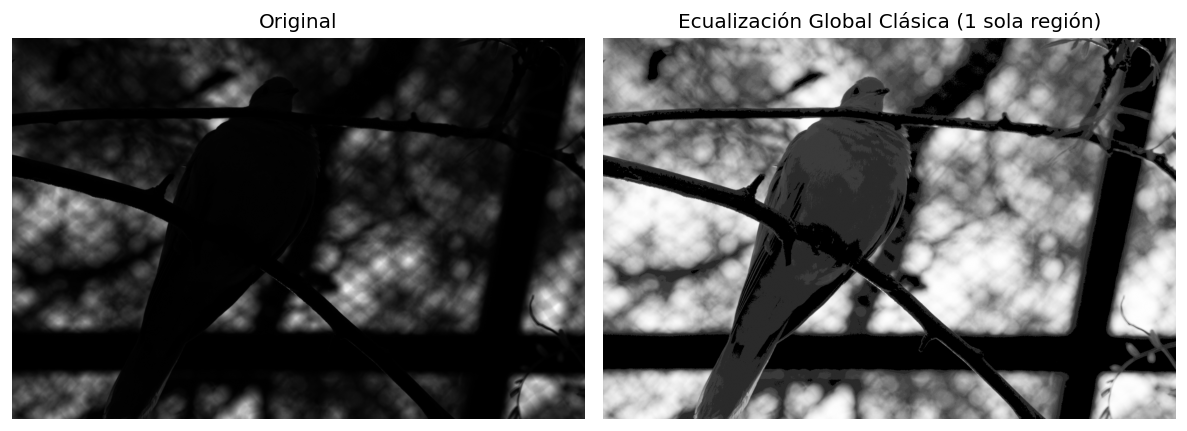

In [6]:
H, W = img_1.shape

# Configuración para que exista una única región que cubra toda la imagen
one_region = max(H, W)

img_global_eq = ecualizacion_local(
    img_1, 
    win_size=one_region, 
    stride=one_region, 
    n_bins=256, 
    clip_limit_factor=1.0
)

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_1, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_global_eq, cmap='gray')
axes[1].set_title('Ecualización Global Clásica (1 sola región)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'verificacion_global.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

La ecualización global logra un buen resultado se observa que los niveles de gris están bien distribuidos en toda la imagen recuperando detalles

### 2) Tamaño regiones y distancia entre regiones

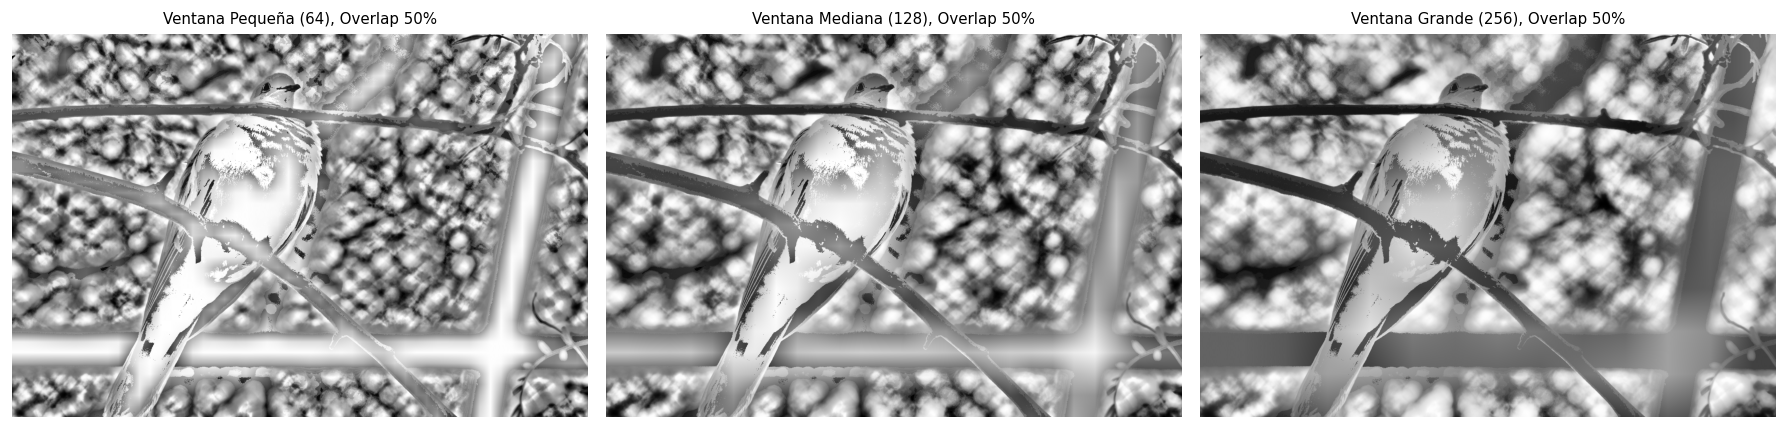

In [7]:
# Explorar Region, mantener solopamiento 50%
config_region = [
    {"win_size": 64, "stride": 32, "label": "Ventana Pequeña (64), Overlap 50%"},
    {"win_size": 128, "stride": 64, "label": "Ventana Mediana (128), Overlap 50%"},
    {"win_size": 256, "stride": 128, "label": "Ventana Grande (256), Overlap 50%"}
]

fig, axes = plt.subplots(1, len(config_region), figsize=(15, 5))

for idx, cfg in enumerate(config_region):
    res = ecualizacion_local(
        img_1, 
        win_size=cfg["win_size"], 
        stride=cfg["stride"], 
        n_bins=256, 
        clip_limit_factor=1.0
    )
    axes[idx].imshow(res, cmap='gray')
    axes[idx].set_title(cfg["label"], fontsize=9)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'explorar_region.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()


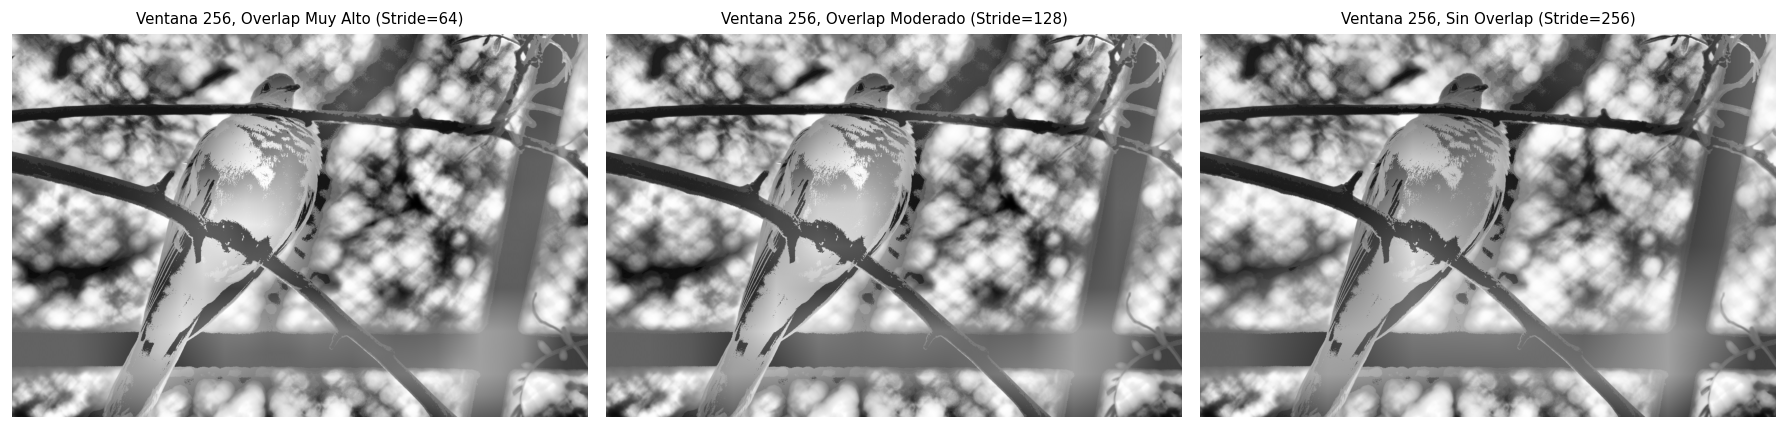

In [ ]:
# Explorar Solapamiento, mantener región 256x256
configs_overlap = [
    {"win_size": 256, "stride": 64,  "label": "Ventana 256, Overlap Muy Alto (Stride=64)"},
    {"win_size": 256, "stride": 128,  "label": "Ventana 256, Overlap Moderado (Stride=128)"},
    {"win_size": 256, "stride": 256, "label": "Ventana 256, Sin Overlap (Stride=256)"},
]

fig, axes = plt.subplots(1, len(configs_overlap), figsize=(15, 5))

for idx, cfg in enumerate(configs_overlap):
    res = ecualizacion_local(
        img_1, 
        win_size=cfg["win_size"], 
        stride=cfg["stride"], 
        n_bins=256, 
        clip_limit_factor=1.0
    )
    axes[idx].imshow(res, cmap='gray')
    axes[idx].set_title(cfg["label"], fontsize=9)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'explorar_overlap.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

El overlap (o grado de solapamiento) representa la proporción de área espacial que comparten dos regiones vecinas dentro de la malla local. 
Un overlap del 50% implica que la distancia entre los centros de regiones adyacentes es igual a la mitad del tamaño de la ventana. 

**Efecto del Tamaño de Región (Fijando Overlap en 50%)**

* **Ventana Pequeña 64x64 píxeles:**
  * **Comportamiento visual:** Genera una amplia amplificación del contraste local y crea ruido.
  * **Artefactos:** Al trabajar sobre regiones muy reducidas, pequeñas variaciones de gris en zonas homogéneas producen CDFs con pendientes muy pronunciadas. Esto introduce ruido granulado severo, bordes marcados e hiper-contrastes artificiales** que no existen en la imagen original.

* **Ventana Mediana 128x128 píxeles:**
  * **Comportamiento visual:** La presencia de ruido disminuye de forma notable respecto a la ventana de 64x64 pero no lo suficiente.
  * **Resultado:** Mismo efecto que en ventana pequeña, pero atenuado.

* **Ventana Grande 256x256 píxeles:**
  * **Comportamiento visual:** Ofrece una distribución de intensidades mucho más continua, homogénea y equilibrada.
  * **Tendencia:** Al aumentar el tamaño del parche, la cantidad de muestras en el histograma local aumenta y su estadística converge hacia el histograma de la imagen completa, aproximándose gradualmente al comportamiento de la ecualización global.

**Efecto del Solapamiento y Densidad de la Malla**

* **Sin Overlap (Stride igual al tamaño de ventana):**
    Al no existir solapamiento físico entre los vecindarios de los centros de la malla, la interpolación bilineal sigue operando para suavizar la transición y no se observan grillas, pero al bajar la densidad la ponderaciónlas CDFs vecinas se reduce a las fronteras (4 regiones adyacentes) sin enriquecerse de otras regiones.Viendose ligereamente más oscura

* **Con Overlap (Stride menor al tamaño de ventana, ej. 50% o más):**
    La superposición espacial incrementa la densidad de centros de la malla, permitiendo que cada píxel reciba una ponderación de un vecindario de regiones mucho más rico.

En general no se observa un efecto notorio en el efecto del solapamiento


### 3) Número de bins y efecto según tamaño de región

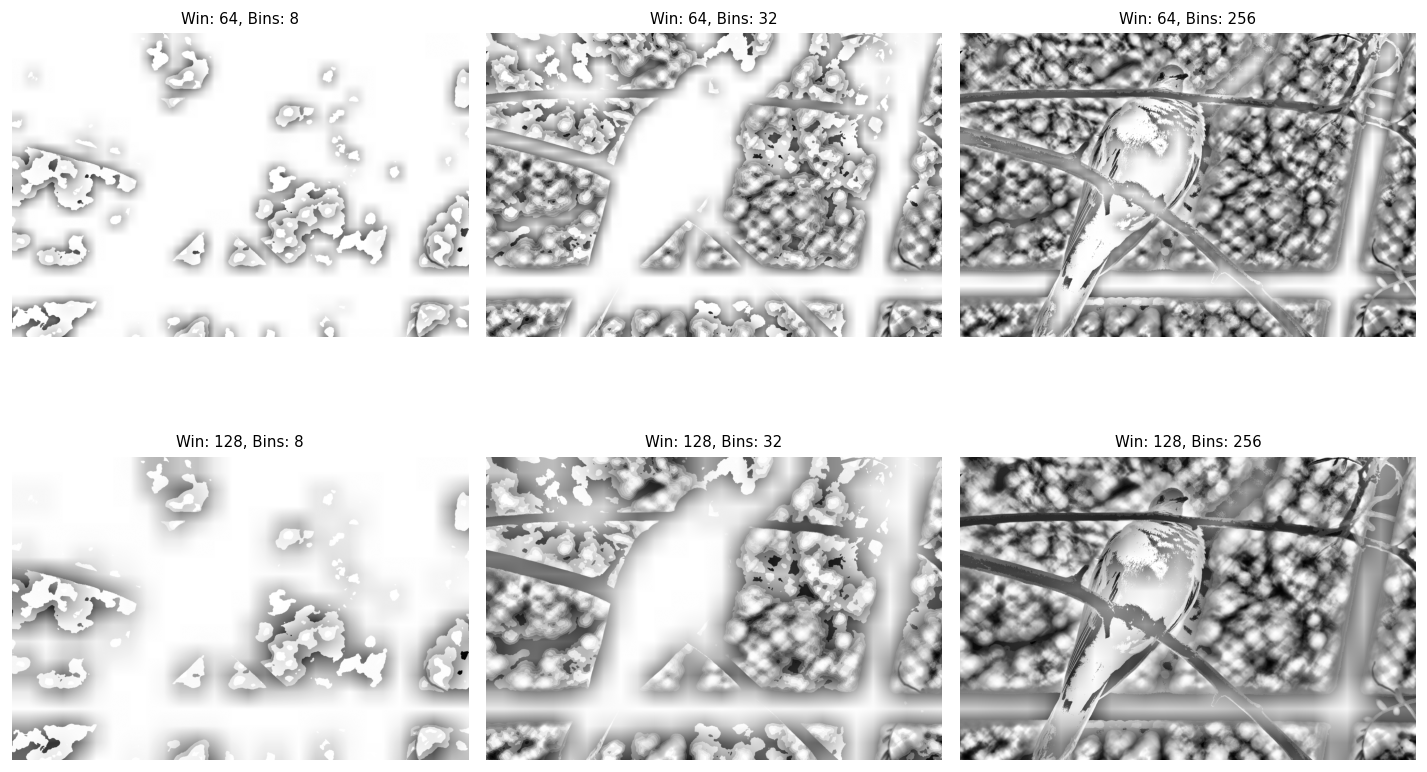

In [17]:
bins_exploracion = [8, 32, 256]
win_sizes = [64, 128]

fig, axes = plt.subplots(len(win_sizes), len(bins_exploracion), figsize=(12, 8))

for i, w_s in enumerate(win_sizes):
    for j, b in enumerate(bins_exploracion):
        res = ecualizacion_local(img_1, win_size=w_s, stride=w_s // 2, n_bins=b, clip_limit_factor=1.0)
        axes[i, j].imshow(res, cmap='gray')
        axes[i, j].set_title(f'Win: {w_s}, Bins: {b}', fontsize=9)
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig(
    os.path.join('results', 'p2', 'numero_bins.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Se evaluó el impacto de variar el número de bins del histograma ($n_{\text{bins}} \in \{8, 32, 256\}$) combinándolo con tamaños de ventana de $64$ y $128$ píxeles:

* **Con un número reducido de bins ($n_{\text{bins}} = 8$):** 
  La imagen se vuelve completamente incomprensible, predominando grandes manchas blancas y una destrucción total de la estructura visual y de los contornos.
* **Con bins intermedios ($n_{\text{bins}} = 32$):** 
  El ruido de fondo se vuelve (sin la textura que permite la escala completa) formando texturas densas, mientras que la zona del pájaro se satura por completo, volviéndose totalmente blanca y perdiendo todos los detalles del plumaje y su forma reconocible.
* **Con el rango completo ($n_{\text{bins}} = 256$):** 
  Se aprovecha adecuadamente la profundidad de bits estándar, permitiendo observar con claridad la forma del pájaro, las ramas y la estructura general de la escena sin saturaciones destructivas (ruido de fondo relacionado a distribución de bins uniforme)
* **Efecto según el tamaño de ventana:** 
  Una mayor área de análisis (ventanas más grandes) permite apreciar un mejor gradiente o difuminado en las transiciones tonales del plumaje del ave, logrando una transición más suave a escala global.

### 4) Exploración de parametros de mecanismo de control de contraste

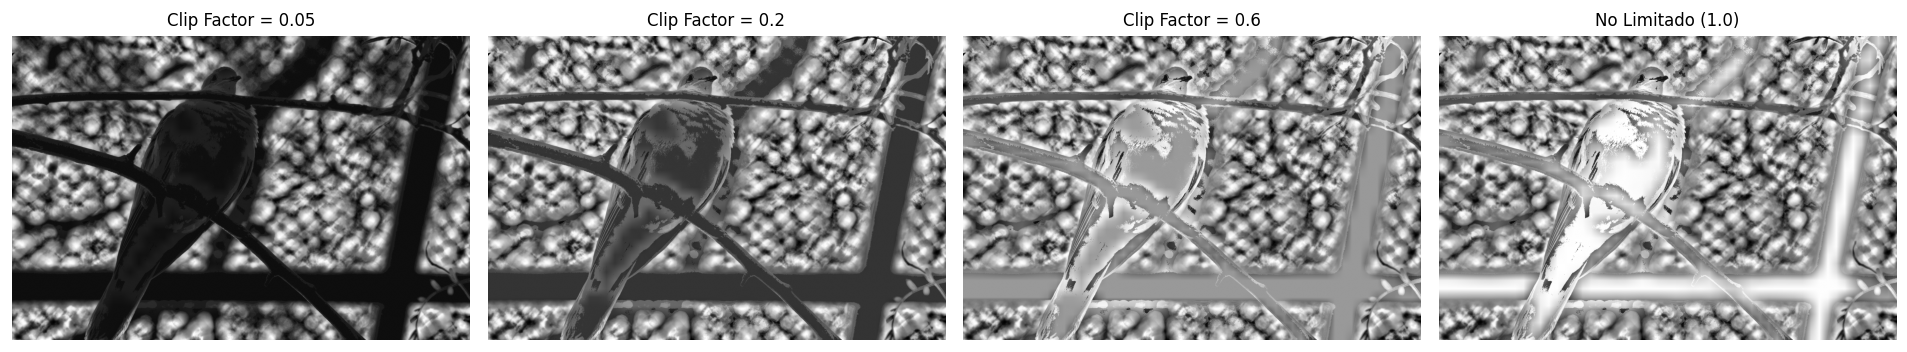

In [20]:
# [Punto 4] Barrido sistemático del factor de control de contraste
factores_clip = [0.05, 0.2, 0.6, 1.0]

fig, axes = plt.subplots(1, len(factores_clip), figsize=(16, 4))

for idx, cf in enumerate(factores_clip):
    res = ecualizacion_local(img_1, win_size=64, stride=32, n_bins=256, clip_limit_factor=cf)
    titulo = "No Limitado (1.0)" if cf >= 1.0 else f"Clip Factor = {cf}"
    axes[idx].imshow(res, cmap='gray')
    axes[idx].set_title(titulo, fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 5) Comparación con CLAHE

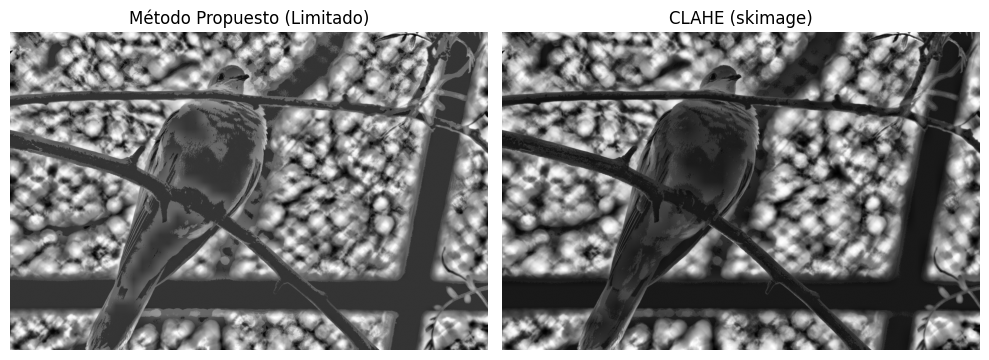

In [ ]:
# Método de limitación propio
mio = ecualizacion_local(img_1, win_size=64, stride=32, n_bins=256, clip_limit_factor=0.2)

# CLAHE de scikit-image
clahe = sk.exposure.equalize_adapthist(img_1, kernel_size=64, clip_limit=0.1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mio, cmap='gray')
axes[0].set_title('Método Propuesto (Limitado)')
axes[0].axis('off')

axes[1].imshow(clahe, cmap='gray')
axes[1].set_title('CLAHE (skimage)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6) Caso Indeseable

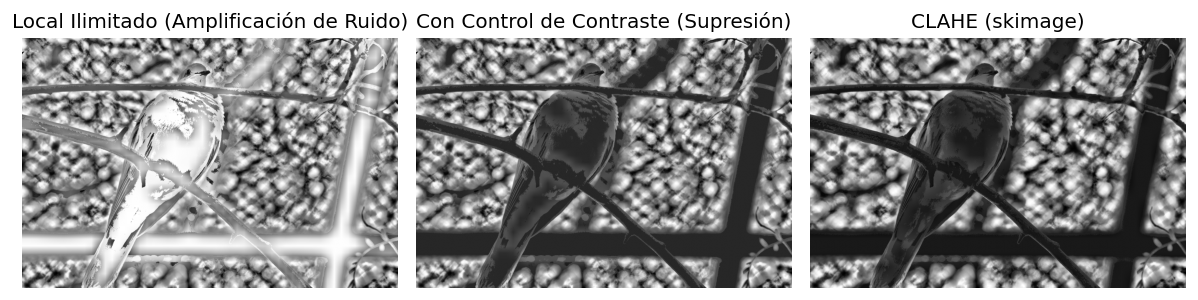

In [22]:
no_limitado = ecualizacion_local(img_1, win_size=64, stride=32, n_bins=256, clip_limit_factor=1.0)
controlado = ecualizacion_local(img_1, win_size=64, stride=32, n_bins=256, clip_limit_factor=0.15)
clahe = sk.exposure.equalize_adapthist(img_1, kernel_size=64, clip_limit=0.1)

fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].imshow(no_limitado, cmap='gray')
axes[0].set_title('Local Ilimitado (Amplificación de Ruido)')
axes[0].axis('off')

axes[1].imshow(controlado, cmap='gray')
axes[1].set_title('Con Control de Contraste (Supresión)')
axes[1].axis('off')

axes[2].imshow(clahe, cmap='gray')
axes[2].set_title('CLAHE (skimage)')
axes[2].axis('off')

plt.tight_layout()
plt.show()